In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

In [4]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)


In [5]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)

Training data shape: (60000, 28, 28)


In [6]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())

Minimum value: -1.0
Maximum value: 1.0


In [7]:
generator = tf.keras.Sequential([
    layers.Dense(256, input_shape=(100,), activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1024, activation="relu"),
    layers.Dense(28 * 28, activation="tanh"),
    layers.Reshape((28, 28))
])

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
noise = tf.random.normal([1, 100])

generated_image = generator(noise)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28)


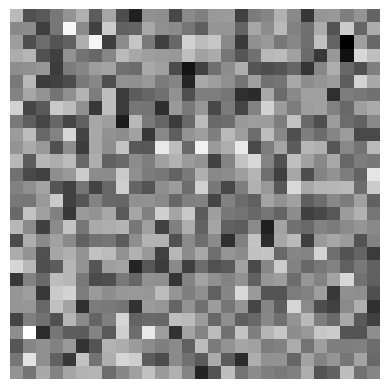

In [9]:
plt.imshow(generated_image[0], cmap="gray")
plt.axis("off")
plt.show()

In [10]:
discriminator = tf.keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
prediction = discriminator(generated_image)

print("Discriminator prediction:", prediction.numpy())

Discriminator prediction: [[0.58097297]]


In [13]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

In [14]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [15]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    return real_loss + fake_loss

In [16]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)

discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)

In [17]:
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(60000).batch(BATCH_SIZE)

In [18]:
@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise)

        real_output = discriminator(images)
        fake_output = discriminator(generated_images)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator,
            generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator,
            discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [19]:
EPOCHS = 20

def train(dataset, epochs):

    for epoch in range(epochs):

        gen_loss_total = 0
        disc_loss_total = 0
        batches = 0

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(image_batch)

            gen_loss_total += gen_loss
            disc_loss_total += disc_loss
            batches += 1

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Generator Loss: {gen_loss_total / batches:.4f} "
            f"- Discriminator Loss: {disc_loss_total / batches:.4f}"
        )

In [20]:
train(train_dataset, EPOCHS)

Epoch 1/20 - Generator Loss: 3.5174 - Discriminator Loss: 0.1486
Epoch 2/20 - Generator Loss: 5.4264 - Discriminator Loss: 0.0360
Epoch 3/20 - Generator Loss: 5.4519 - Discriminator Loss: 0.4460
Epoch 4/20 - Generator Loss: 2.6677 - Discriminator Loss: 0.7797
Epoch 5/20 - Generator Loss: 1.9467 - Discriminator Loss: 0.7799
Epoch 6/20 - Generator Loss: 1.8608 - Discriminator Loss: 0.9227
Epoch 7/20 - Generator Loss: 1.8127 - Discriminator Loss: 0.8839
Epoch 8/20 - Generator Loss: 1.9287 - Discriminator Loss: 0.7383
Epoch 9/20 - Generator Loss: 2.2015 - Discriminator Loss: 0.7642
Epoch 10/20 - Generator Loss: 2.3629 - Discriminator Loss: 0.9175
Epoch 11/20 - Generator Loss: 1.9290 - Discriminator Loss: 1.1092
Epoch 12/20 - Generator Loss: 2.1293 - Discriminator Loss: 0.9739
Epoch 13/20 - Generator Loss: 2.1876 - Discriminator Loss: 0.9467
Epoch 14/20 - Generator Loss: 2.1397 - Discriminator Loss: 0.7689
Epoch 15/20 - Generator Loss: 2.4895 - Discriminator Loss: 0.9168
Epoch 16/20 - Gener

In [21]:
noise = tf.random.normal([16, 100])

generated_images = generator(noise)

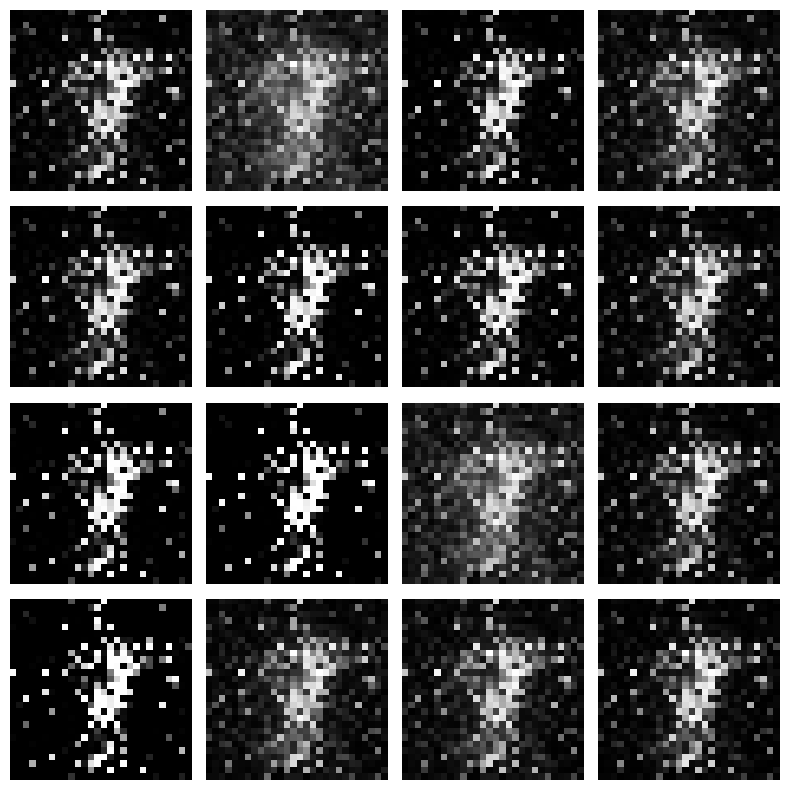

In [22]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()